# News Topic Classification System

## Step 1: Import Required Libraries

In [6]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import re 
import nltk 
from nltk.corpus import stopwords
nltk.download('stopwords')
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report,f1_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

[nltk_data] Downloading package stopwords to C:\Users\TECH
[nltk_data]     CLUB\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


## Step 2: Load Dataset

In [2]:
df=pd.read_csv("inshort_news_data-1.csv")
df.head()

,Unnamed: 0,news_headline,news_article,news_category
0,0,50-year-old problem of biology solved by Artif...,DeepMind's AI system 'AlphaFold' has been reco...,technology
1,1,Microsoft Teams to stop working on Internet Ex...,Microsoft Teams will stop working on Internet ...,technology
2,2,Hope US won't erect barriers to cooperation: C...,"China, in response to reports of US adding Chi...",technology
3,3,Global smartphone sales in Q3 falls 5.7% to 36...,The global smartphone sales in the third quart...,technology
4,4,EU hoping Biden will clarify US position on di...,The European Union (EU) is hoping that US Pres...,technology


## Step 3: Check Dataset Info & Missing Values

In [4]:
print("Dataset Shape:" , df.shape)

print("\n Missing Values per Column:\n",df.isnull().sum())

Dataset Shape: (4817, 4)

 Missing Values per Column:
 Unnamed: 0       0
news_headline    0
news_article     0
news_category    0
dtype: int64


## Step 4: Text Preprocessing

In [7]:
stop_words= set(stopwords.words('english'))
# Function to clean text
def clean_text(text):
    # Lowercase + remove punctuation/numbers
    text = re.sub(r'[^a-zA-Z\s]', '', str(text)).lower()
    
    # Split words and join back
    return " ".join(text.split())

# Apply cleaning on news_article column
df['cleaned_text'] = df['news_article'].apply(clean_text)

# Show sample
df[['news_article', 'cleaned_text']].head()


,news_article,cleaned_text
0,DeepMind's AI system 'AlphaFold' has been reco...,deepminds ai system alphafold has been recogni...
1,Microsoft Teams will stop working on Internet ...,microsoft teams will stop working on internet ...
2,"China, in response to reports of US adding Chi...",china in response to reports of us adding chin...
3,The global smartphone sales in the third quart...,the global smartphone sales in the third quart...
4,The European Union (EU) is hoping that US Pres...,the european union eu is hoping that us presid...


## Step 5: Convert Text to Numerical Features using TF-IDF

In [11]:


# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)  

# Fit and transform the cleaned text
X = tfidf.fit_transform(df['cleaned_text'])

# Show shape
print("TF-IDF Matrix Shape:", X.shape)


TF-IDF Matrix Shape: (4817, 5000)


## Step 6: Train ML Model for News Classification 

In [12]:


# Target variable
y = df['news_category']  # News category column

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --------- Naive Bayes ---------
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
nb_acc=accuracy_score(y_test,y_pred_nb)
print("Naive Bayes Accuracy:", nb_acc)
print(classification_report(y_test, y_pred_nb))

# --------- SVM ---------
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
svm_acc=accuracy_score(y_test,y_pred_svm)
print("SVM Accuracy:", svm_acc)
print(classification_report(y_test, y_pred_svm))

Naive Bayes Accuracy: 0.8890041493775933
               precision    recall  f1-score   support

   automobile       0.96      0.62      0.76        40
entertainment       0.89      0.97      0.93       182
     politics       0.98      0.93      0.95       110
      science       0.94      0.54      0.69        87
       sports       0.98      0.97      0.97       172
   technology       0.82      0.88      0.85       156
        world       0.82      0.94      0.87       217

     accuracy                           0.89       964
    macro avg       0.91      0.83      0.86       964
 weighted avg       0.90      0.89      0.88       964

SVM Accuracy: 0.9346473029045643
               precision    recall  f1-score   support

   automobile       0.89      1.00      0.94        40
entertainment       0.94      0.98      0.96       182
     politics       0.97      1.00      0.99       110
      science       0.93      0.86      0.89        87
       sports       0.98      0.97      0.

## Step 7: Evaluate Model Performance using Confusion Matrix

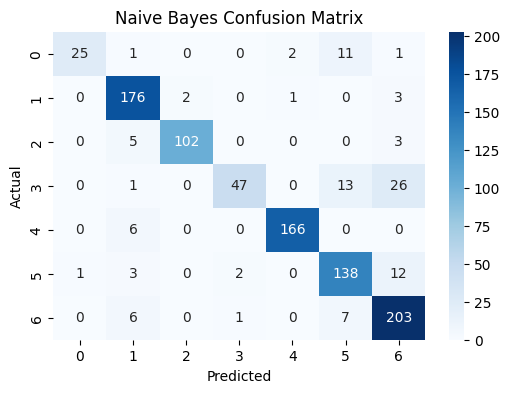

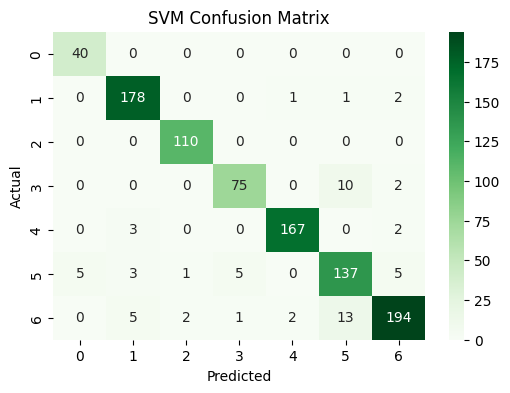

In [13]:


# Naive Bayes Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,4))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues")
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# SVM Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,4))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Greens")
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
## Step 8: Final Observation

Naive Bayes -> Accuracy: 0.89, F1-Score: 0.88
SVM         -> Accuracy: 0.93, F1-Score: 0.93


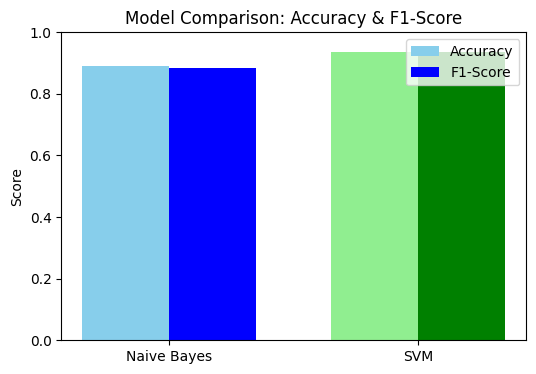

Observation: SVM model performed better overall in terms of accuracy and F1-Score.


In [14]:




# Weighted F1-Score (multi-class)
nb_f1 = f1_score(y_test, y_pred_nb, average='weighted')
svm_f1 = f1_score(y_test, y_pred_svm, average='weighted')

# Print results
print("Naive Bayes -> Accuracy: {:.2f}, F1-Score: {:.2f}".format(nb_acc, nb_f1))
print("SVM         -> Accuracy: {:.2f}, F1-Score: {:.2f}".format(svm_acc, svm_f1))

# ----------------- Visual comparison using side-by-side bar chart -----------------
models = ['Naive Bayes', 'SVM']
accuracy = [nb_acc, svm_acc]
f1 = [nb_f1, svm_f1]

x = np.arange(len(models))  # X positions
width = 0.35                # width of bars

plt.figure(figsize=(6,4))
plt.bar(x - width/2, accuracy, width, label='Accuracy', color=['skyblue','lightgreen'])
plt.bar(x + width/2, f1, width, label='F1-Score', color=['blue','green'])

plt.xticks(x, models)
plt.ylabel('Score')
plt.ylim(0,1)
plt.title('Model Comparison: Accuracy & F1-Score')
plt.legend()
plt.show()

# ----------------- Observation -----------------
if svm_acc > nb_acc:
    print("Observation: SVM model performed better overall in terms of accuracy and F1-Score.")
else:
    print("Observation: Naive Bayes model performed better overall in terms of accuracy and F1-Score.")